In [ ]:
"""
Implementation of Parallelized Extreme Learning Machine (P-ELM)
Target: Online Data Classification & DevOps Anomaly Detection

Author: Amanda Taheri
Based on the research paper:
Title: Parallelized Extreme Learning Machine for Online Data Classification
https://doi.org/10.1007/s10489-022-03308-7
Copyright (c) 2026. All rights reserved.

"""

In [18]:
# 1. Import necessary libraries
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Add the src directory to the path so we can import our ELM class from elm.py
sys.path.append(os.path.abspath(os.path.join('..')))
from src.elm_base import ELMBase

print("Environment is ready!")


Environment is ready!


In [13]:
# 2. Simulate DevOps Monitoring Data
def generate_devops_data(n_samples=4000):
    np.random.seed(7)
    
    # Healthy System (Normal behavior)
    normal_data = np.random.normal(loc=30, scale=5, size=(n_samples // 2, 4))
    normal_labels = np.zeros(n_samples // 2)
    
    # Anomalous System (High load / Potential Incident)
    anomaly_data = np.random.normal(loc=70, scale=12, size=(n_samples // 2, 4))
    anomaly_labels = np.ones(n_samples // 2)
    
    # Merge, Scale and Split
    X = np.vstack([normal_data, anomaly_data])
    y = np.concatenate([normal_labels, anomaly_labels])
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = generate_devops_data()
print(f"Dataset generated: {X_train.shape[0]} training and {X_test.shape[0]} testing samples.")


Dataset generated: 3200 training and 800 testing samples.


In [14]:
# 3. Initialize and Train the Base ELM
# We start with 50 hidden neurons
model = ELMBase(input_size=4, hidden_size=50, activation='sigmoid')

# The magic one-step training
model.fit(X_train, y_train)

print("Model training complete!")


Model fitted. Output weights shape: (50,)
Model training complete!


In [15]:
# 4. Predict and Analyze Results
y_pred_raw = model.predict(X_test)
y_pred = (y_pred_raw > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed Report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Anomaly']))


Accuracy: 100.00%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       422
     Anomaly       1.00      1.00      1.00       378

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



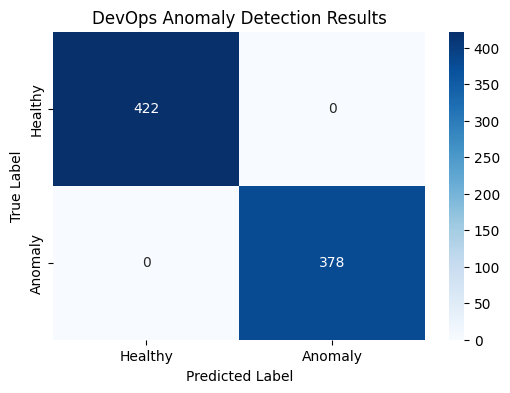

In [16]:
# 5. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Anomaly'], yticklabels=['Healthy', 'Anomaly'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DevOps Anomaly Detection Results')
plt.show()
